In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/sreekanniga/Data-Cleaning-and-Reporting-Automation/main/data.xlsx"
df = pd.read_excel(url)
df.head()

,School DBN,Date,Enrolled,Absent,Present,Released
0,01M015,20180905,172,19,153,0
1,01M015,20180906,171,17,154,0
2,01M015,20180907,172,14,158,0
3,01M015,20180912,173,7,166,0
4,01M015,20180913,173,9,164,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277153 entries, 0 to 277152
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   School DBN  277153 non-null  object
 1   Date        277153 non-null  int64 
 2   Enrolled    277153 non-null  int64 
 3   Absent      277153 non-null  int64 
 4   Present     277153 non-null  int64 
 5   Released    277153 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 12.7+ MB


In [ ]:
df.isnull().sum()

,0
School DBN,0
Date,0
Enrolled,0
Absent,0
Present,0
Released,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m%d')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
df['Attendance %'] = (df['Present'] / df['Enrolled']) * 100

In [ ]:
df.head()

,School DBN,Date,Enrolled,Absent,Present,Released,Year,Month,Attendance %
0,01M015,2018-09-05,172,19,153,0,2018,9,88.953488
1,01M015,2018-09-06,171,17,154,0,2018,9,90.058480
2,01M015,2018-09-07,172,14,158,0,2018,9,91.860465
3,01M015,2018-09-12,173,7,166,0,2018,9,95.953757
4,01M015,2018-09-13,173,9,164,0,2018,9,94.797688


In [ ]:
df['Attendance %'].mean()

np.float64(89.79207178646993)

In [ ]:
top_schools = df.groupby('School DBN')['Attendance %'].mean()

top_schools.sort_values(ascending=False).head(10)

,Attendance %
School DBN,
12X321,100.000000
12X092,100.000000
08X519,100.000000
02M545,98.455615
20K187,98.296232
20K105,98.195937
02M312,98.169758
20K310,98.150601
02M439,98.121336


In [ ]:
top_schools.sort_values().head(10)

,Attendance %
School DBN,
79Q344,30.069647
79M331,41.511856
02M560,43.789864
13K616,46.290679
21K728,49.177240
17K646,49.756705
16K669,52.014963
25Q540,52.179131
08X537,53.110463


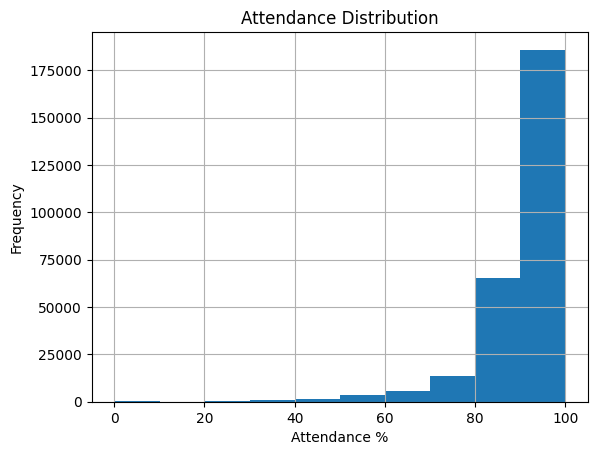

In [ ]:
import matplotlib.pyplot as plt

df['Attendance %'].hist()
plt.title("Attendance Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Frequency")
plt.show()

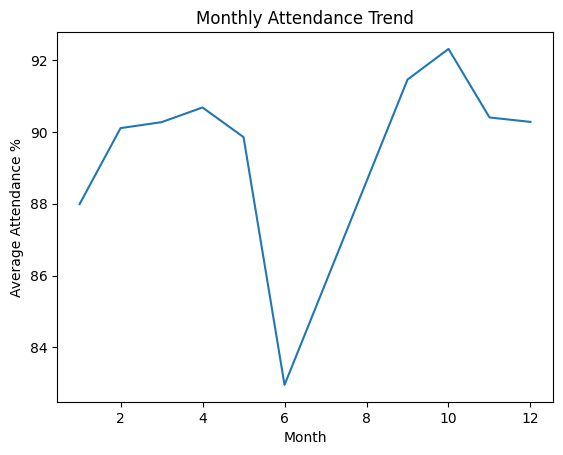

In [ ]:
monthly = df.groupby('Month')['Attendance %'].mean()

monthly.plot()
plt.title("Monthly Attendance Trend")
plt.ylabel("Average Attendance %")
plt.show()

In [ ]:
df.to_excel("cleaned_attendance.xlsx", index=False)